# Carnet 03 : Étude d'Ablation (Feature Ablation Study)
**Auteur :** Kaan BILGIC
**Projet :** Détection d'anomalies IoT par Machine Learning

**Objectif de ce carnet :** Ce script démontre la vulnérabilité des modèles de détection. En retirant progressivement les caractéristiques fallacieuses (Spurious feature)" (Adresses IP, Ports, Payloads), nous observons l'effondrement des performances (F1-Score) et l'augmentation des attaques manquées (Faux Négatifs).
---

In [1]:
## 1. Initialisation de l'environnement

import pandas as pd
import numpy as np
import joblib
import os
import tensorflow as tf
from sklearn.metrics import f1_score

print("--- Chargement du Laboratoire d'Ablation ---")
model_dir = "../models"
# 1. Rechargement des "Cerveaux" (Modèles et Scaler)
scaler_phase3 = joblib.load(os.path.join(model_dir, 'scaler_phase3.pkl'))
iso_forest_v2 = joblib.load(os.path.join(model_dir, 'isolation_forest_V2_3M.pkl'))
autoencoder_v2 = tf.keras.models.load_model(os.path.join(model_dir, 'autoencoder_V2_3M.keras'))
seuil_ae = joblib.load(os.path.join(model_dir, 'seuil_ae_V2.pkl'))

print("Modèles SOTA, Scaler et Seuil chargés en RAM.")

--- Chargement du Laboratoire d'Ablation ---
Modèles SOTA, Scaler et Seuil chargés en RAM.


--- Début de l'Étude d'Ablation (Feature Ablation) ---
Dataset mixte chargé : 90726 lignes.

Évaluation du Baseline (Complet)...
 -> F1-Score : 0.5660 | Attaques manquées (FN) : 16361

Évaluation du Scénario A (Sans Payloads)...
 -> F1-Score : 0.5608 | Attaques manquées (FN) : 16588

Évaluation du Scénario B (Sans Payloads ni IP/Ports)...
 -> F1-Score : 0.5224 | Attaques manquées (FN) : 18238

Évaluation du Scénario C (Stérilisation Totale)...
 -> F1-Score : 0.4043 | Attaques manquées (FN) : 23330

Étude d'ablation terminée. Graphique sauvegardé : ../images/Feature_Ablation_Curve.png


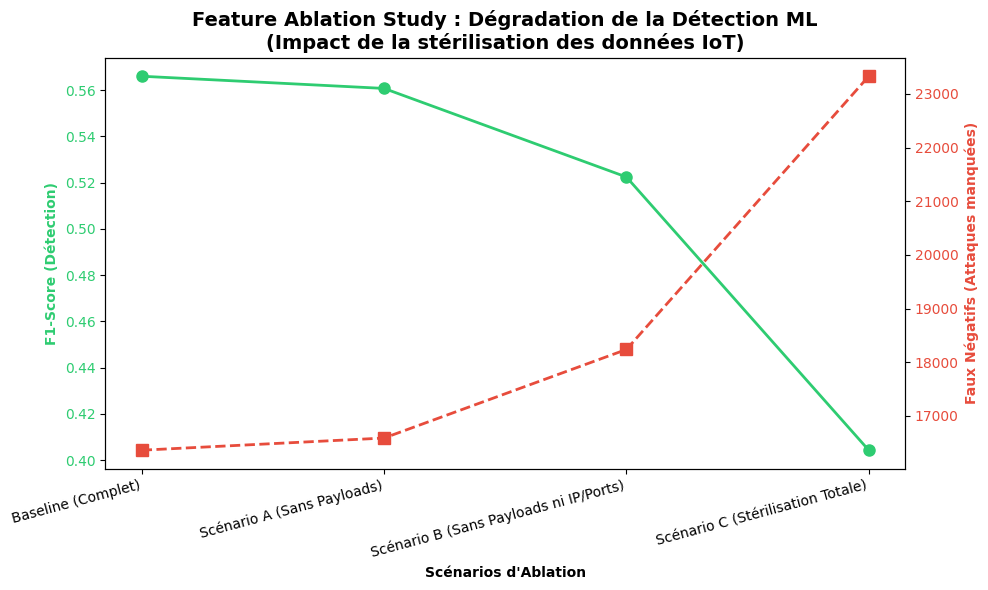

In [2]:
## 2. Chargement des données et Scénarios d'Ablation

import pandas as pd
import numpy as np
import glob
import os
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, confusion_matrix
import matplotlib.pyplot as plt

print("--- Début de l'Étude d'Ablation (Feature Ablation) ---")

# ==========================================
# 1. CHARGEMENT DES DONNÉES (Échantillons GitHub)
# ==========================================
# Chargement du trafic normal
df_norm = pd.read_csv("../data/sample_Normal_Traffic.csv", low_memory=False)
# On prend 50 000 lignes max
df_norm = df_norm.sample(n=min(50000, len(df_norm)), random_state=42)
df_norm['Ground_Truth'] = 1

# Chargement du trafic d'attaques mélangées
df_mixte_complet = pd.read_csv("../data/sample_DNN-EdgeIIoT.csv", low_memory=False)
df_att = df_mixte_complet[df_mixte_complet['Attack_type'] != 'Normal'].copy()
# On prend 50 000 lignes max pour équilibrer
df_att = df_att.sample(n=min(50000, len(df_att)), random_state=42)
df_att['Ground_Truth'] = -1

df_mixte = pd.concat([df_norm, df_att], ignore_index=True)
y_vrai = df_mixte['Ground_Truth'].values

print(f"Dataset mixte chargé : {df_mixte.shape[0]} lignes.")

# ==========================================
# 2. DÉFINITION DES SCÉNARIOS D'ABLATION
# ==========================================
# 1. Famille Réseau de base
famille_IP = ['ip.src_host', 'ip.dst_host', 'arp.dst.proto_ipv4', 'arp.src.proto_ipv4']
famille_Ports = ['tcp.srcport', 'udp.port', 'tcp.dstport']

# 2. Famille Volumétrique et Textuelle (On ajoute http.content_length !)
famille_Payloads = [
    'http.request.uri.query', 'http.request.full_uri', 'tcp.payload', 'mqtt.msg', 'mqtt.topic',
    'http.content_length', 'mbtcp.len', 'mqtt.topic_len', 'mqtt.proto_len'
]

# 3. Famille des Artefacts de Capture (Les corrélations fallacieuses du Carnet 02)
famille_Artefacts = [
    'tcp.flags', 'tcp.connection.syn', 'mqtt.ver', 'http.tls_port',
    'mqtt.conflag.cleansess', 'dns.qry.qu', 'tcp.ack', 'tcp.seq',
    'tcp.ack_raw', 'tcp.seq_raw', 'tcp.checksum', 'icmp.checksum',
    'icmp.seq_le', 'mbtcp.trans_id', 'dns.qry.name.len', 'mqtt.conack.flags'
]

# Colonnes inutiles/parasites à enlever dans tous les cas
cols_base_drop = ['frame.time', 'Attack_label', 'Attack_type', 'Ground_Truth', 'Source_Sensor']

scenarios = {
    "Baseline (Complet)": cols_base_drop,
    
    # Étape 1 : On enlève le "bruit" textuel en premier. 
    "Scénario A (Sans Payloads)": cols_base_drop + famille_Payloads,
    
    # Étape 2 : Le modèle est propre, on commence à l'aveugler en retirant les identifiants réseau.
    "Scénario B (Sans Payloads ni IP/Ports)": cols_base_drop + famille_Payloads + famille_IP + famille_Ports,
    
    # Étape 3 : Le coup de grâce, on enlève les artefacts de capture (la triche).
    "Scénario C (Stérilisation Totale)": cols_base_drop + famille_Payloads + famille_IP + famille_Ports + famille_Artefacts
}

# Variables pour stocker les résultats
f1_scores = []
faux_negatifs = []
labels_scenarios = list(scenarios.keys())

# ==========================================
# 3. BOUCLE D'ENTRAÎNEMENT ET D'ÉVALUATION
# ==========================================
for nom, colonnes_a_retirer in scenarios.items():
    print(f"\nÉvaluation du {nom}...")
    
    from sklearn.preprocessing import LabelEncoder
    
    from sklearn.preprocessing import LabelEncoder
    from pandas.api.types import is_numeric_dtype
    
    # 3.1 Ablation (Retrait des colonnes)
    X_ablated = df_mixte.drop(columns=[col for col in colonnes_a_retirer if col in df_mixte.columns]).copy()
    
    # Encodage intelligent et blindé (Label Encoding)
    X_num = pd.DataFrame()
    for col in X_ablated.columns:
        # Si la colonne N'EST PAS strictement numérique (texte, IP, types mixtes...)
        if not is_numeric_dtype(X_ablated[col]):
            le = LabelEncoder()
            X_num[col] = le.fit_transform(X_ablated[col].astype(str))
        else:
            X_num[col] = X_ablated[col]
            
    X_num = X_num.fillna(0)
    
    # Normalisation
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_num)
    
    # 3.2 Entraînement rapide sur l'Isolation Forest
    iso = IsolationForest(n_estimators=100, contamination=0.5, random_state=42, n_jobs=-1)
    y_pred = iso.fit_predict(X_scaled)
    
    # 3.3 Enregistrement des métriques
    f1 = f1_score(y_vrai, y_pred, pos_label=-1)
    cm = confusion_matrix(y_vrai, y_pred, labels=[1, -1])
    fn = cm[1][0] # Attaques manquées
    
    f1_scores.append(f1)
    faux_negatifs.append(fn)
    print(f" -> F1-Score : {f1:.4f} | Attaques manquées (FN) : {fn}")

# ==========================================
# 4. GÉNÉRATION DU GRAPHIQUE POUR LE RAPPORT
# ==========================================
fig, ax1 = plt.subplots(figsize=(10, 6))

color = '#2ecc71'
ax1.set_xlabel('Scénarios d\'Ablation', fontweight='bold')
ax1.set_ylabel('F1-Score (Détection)', color=color, fontweight='bold')
ax1.plot(labels_scenarios, f1_scores, marker='o', color=color, linewidth=2, markersize=8, label="F1-Score")
ax1.tick_params(axis='y', labelcolor=color)
plt.xticks(rotation=15, ha='right')

# Création d'un axe jumeau pour les Faux Négatifs
ax2 = ax1.twinx()
color2 = '#e74c3c'
ax2.set_ylabel('Faux Négatifs (Attaques manquées)', color=color2, fontweight='bold')
ax2.plot(labels_scenarios, faux_negatifs, marker='s', color=color2, linewidth=2, markersize=8, linestyle='--', label="Faux Négatifs")
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Feature Ablation Study : Dégradation de la Détection ML\n(Impact de la stérilisation des données IoT)', fontsize=14, fontweight='bold')
fig.tight_layout()

# Sauvegarde du graphique
# Sauvegarde du graphique dans le bon dossier
os.makedirs("../images", exist_ok=True)
chemin_image = "../images/Feature_Ablation_Curve.png"
plt.savefig(chemin_image, dpi=300, bbox_inches='tight')
print(f"\nÉtude d'ablation terminée. Graphique sauvegardé : {chemin_image}")
plt.show()